# Viscoelastic FWI: recovering an attenuation anomaly

This notebook inverts **attenuation** — not velocity — from crosswell data.
The model is homogeneous in $v_p$, $v_s$ and $\rho$; the only thing that
distinguishes the true model from the starting one is a circular anomaly in
$\tau_s$, the shear relaxation level. Anything the inversion recovers therefore
has to come from the attenuation kernels.

It is the small-scale rehearsal for the CO$_2$-storage example of

> Fabien-Ouellet, G. (2017). *Inversion des formes d'ondes complètes
> viscoélastique.* PhD thesis, INRS.

For where the gradient expressions come from, see the companion notebook
[ViscoelasticGradientTheory](ViscoelasticGradientTheory.ipynb).

### What you need

A SeisCL build on `PATH` and a GPU. Viscoelastic gradients require
`back_prop_type=2` (the frequency-domain method): `back_prop_type=1` rejects
`L>0` outright, because reverse-time reconstruction of a dissipative medium is
unconditionally unstable.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# The experiment definition and the FWI driver live next to the notebook as
# plain modules, so they can also be run headless.
import sys
sys.path.insert(0, os.path.join(os.getcwd(), "..", "..", "..", "examples"))
import visco_crosswell as vc
from visco_inversion import Inversion

workdir = os.environ.get("VISCO_WORKDIR", os.path.abspath("_nb_visco"))
os.makedirs(workdir, exist_ok=True)
print("grid %dx%d, dh=%.0f m, dt=%.1e s, NT=%d, f0=%.0f Hz, L=%d mechanism(s) at %s Hz"
      % (vc.NZ, vc.NX, vc.DH, vc.DT, vc.NT, vc.F0, vc.L, vc.FL))

grid 120x80, dh=5 m, dt=4.0e-04 s, NT=1500, f0=60 Hz, L=1 mechanism(s) at [60.] Hz


## 1. The experiment

Two vertical wells: sources down the left one, receivers down the right one.
The medium is a generalized standard linear solid (GSLS) with a single
relaxation mechanism centred on the source frequency.

`taus` is SeisCL's relaxation-time parameter, **not** $Q$ — `SeisCL/Q_tau.py`
converts between them. Background is near-elastic (`taus = 0.002`); the
inclusion is strongly attenuating (`taus = 0.052`).

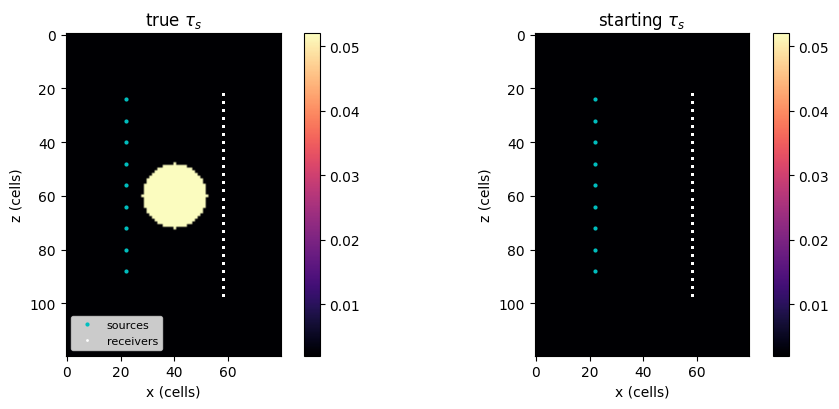

In [2]:
true_model  = vc.circular_inclusion(dtaup=0.0, dtaus=0.05)
start_model = vc.background()

s = vc.make_seiscl(workdir)
src = s.src_pos_all[[0, 2], :] / vc.DH
rec = s.rec_pos_all[[0, 2], :] / vc.DH

fig, ax = plt.subplots(1, 2, figsize=(10, 4.2))
for a, m, t in zip(ax, (true_model["taus"], start_model["taus"]),
                   ("true $\\tau_s$", "starting $\\tau_s$")):
    im = a.imshow(m, cmap="magma", vmin=0.002, vmax=0.052)
    a.plot(src[0], src[1], "c.", ms=4, label="sources")
    a.plot(rec[0], rec[1], "w.", ms=2, label="receivers")
    a.set_title(t); a.set_xlabel("x (cells)"); a.set_ylabel("z (cells)")
    plt.colorbar(im, ax=a, fraction=0.046)
ax[0].legend(loc="lower left", fontsize=8)
plt.tight_layout()

## 2. Forward modelling

Only $\tau_s$ differs between the two models, so the difference in the
seismograms is purely an attenuation effect: the wave through the inclusion
arrives with the same traveltime but lower amplitude and a shifted phase.

observed data: (1500, 130)   max|p| = 1.967e-05


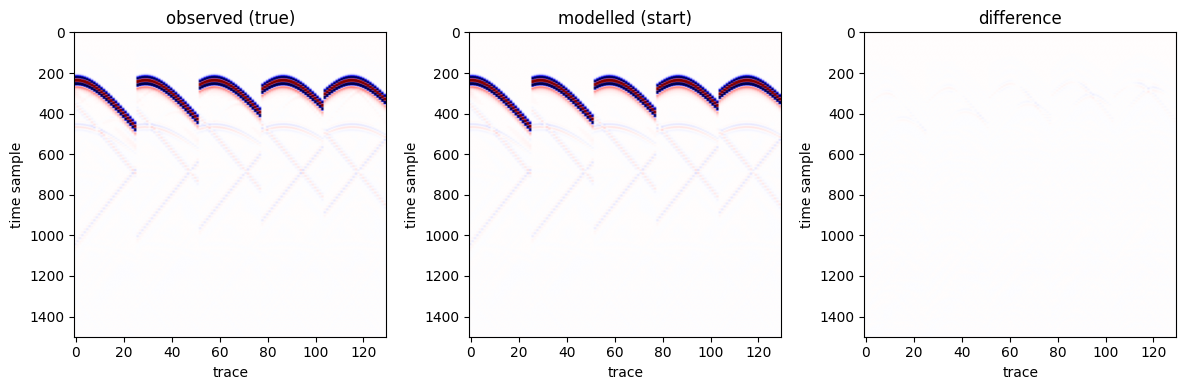

In [3]:
inv = Inversion(workdir, true_model, start_model,
                gradfreqs=[40., 60., 80.], invert=("taus",),
                nshot=5, mute=8.0, smooth=4.0)

d_obs = inv.dobs[0]                      # modelled with the true model
d_ini = inv.forward(start_model)[0]      # modelled with the starting model
print("observed data: %s   max|p| = %.3e" % (d_obs.shape, np.abs(d_obs).max()))

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
cl = np.abs(d_obs).max() * 0.3
for a, d, t in zip(ax, (d_obs, d_ini, d_obs - d_ini),
                   ("observed (true)", "modelled (start)", "difference")):
    a.imshow(d, aspect="auto", cmap="seismic", vmin=-cl, vmax=cl)
    a.set_title(t); a.set_xlabel("trace"); a.set_ylabel("time sample")
plt.tight_layout()

## 3. The gradient

`back_prop_type=2` DFT-accumulates the forward and adjoint wavefields at the
frequencies in `gradfreqs` and cross-correlates them afterwards
(`src/calc_grad.c`). The misfit is computed **in Python** and fed back with
`inputres=1`, so the gradient corresponds to exactly the $J$ we plot.

Three practical points, each of which cost real debugging time — the notebook
records them because none is obvious from the API:

**a) The gradient is right only up to one global constant.** The engine scales
the adjoint source (`res_scale`), so $\nabla J$ as returned is proportional to
the true gradient, not equal to it. Here $J \sim 10^{-11}$ against a gradient
$\sim 10^{-22}$. Any optimiser that trusts both numbers together — L-BFGS-B
does — fails. `Inversion.calibrate()` recovers the constant by finite
differences; `run()` sidesteps it entirely by using the gradient only as a
*direction*.

**b) The gradient is wrong near the sources.** Probing it with localized bumps
gives a consistent ratio $\mathrm{FD}/\langle g,v\rangle \approx 1.8\times10^8$
across the interior but the **wrong sign** on every bump covering an active
shot. Near-source contamination is standard in FWI and routinely muted;
`Inversion(mute=8.0)` drops cells within 8 cells of any source or receiver.

**c) `cropgrad` zeroes the gradient over the absorbing strip**, but $J$ still
depends on those cells. Leaving them among the unknowns makes the problem
inconsistent. `Inversion` restricts the unknowns to the cells where the
gradient is actually defined.

J0 = 1.0085e-11     max|grad| = 1.176e-22


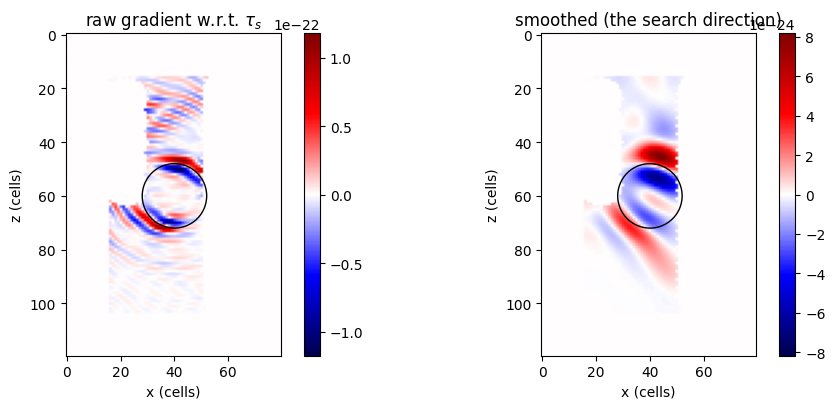

In [4]:
J0, g = inv.fun(inv.x0())
G = np.zeros(inv.mask.shape); G[inv.mask] = g
print("J0 = %.4e     max|grad| = %.3e" % (J0, np.abs(G).max()))

fig, ax = plt.subplots(1, 2, figsize=(10, 4.2))
cl = np.abs(G).max()
im = ax[0].imshow(G, cmap="seismic", vmin=-cl, vmax=cl)
ax[0].set_title("raw gradient w.r.t. $\\tau_s$"); plt.colorbar(im, ax=ax[0], fraction=0.046)
Gp = np.zeros(inv.mask.shape); Gp[inv.mask] = inv.precondition(g)
im = ax[1].imshow(Gp, cmap="seismic", vmin=-np.abs(Gp).max(), vmax=np.abs(Gp).max())
ax[1].set_title("smoothed (the search direction)"); plt.colorbar(im, ax=ax[1], fraction=0.046)
for a in ax:
    a.contour((np.indices(G.shape)[0]-60.)**2 + (np.indices(G.shape)[1]-40.)**2,
              [12.**2], colors="k", linewidths=1)
    a.set_xlabel("x (cells)"); a.set_ylabel("z (cells)")
plt.tight_layout()

The black circle is the true anomaly. The gradient is negative inside it
— so $-g$ correctly pushes $\tau_s$ **up** there — and positive in the halo
around it.

### Is it really a descent direction?

Worth checking quantitatively rather than trusting the picture. Project the
gradient onto a set of localized bumps and compare each projection against a
finite difference of $J$. If the gradient is right up to a constant, the two
lie on a straight line through the origin.

*(This costs a couple of dozen extra forward runs; set `RUN_PROBE=0` to skip.)*

Pearson r = 0.9955     constant = 1.595e+08     signs agreeing: 20/20


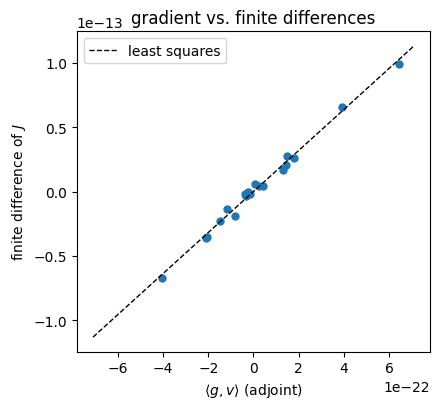

In [5]:
if os.environ.get("RUN_PROBE", "1") == "1":
    zz, xx = np.indices(inv.mask.shape)
    x0 = inv.x0(); gv = []; fd = []
    for z in np.arange(30, 100, 14):
        for x in np.arange(28, 56, 9):
            v = np.exp(-((zz-z)**2 + (xx-x)**2)/(2*5.**2))[inv.mask]
            v /= np.abs(v).max()
            gv.append(float(g @ v))
            fd.append((inv.Jonly(x0 + 0.5*v) - inv.Jonly(x0 - 0.5*v))/1.0)
    gv = np.array(gv); fd = np.array(fd)
    cst = float(gv @ fd)/float(gv @ gv)
    print("Pearson r = %.4f     constant = %.3e     signs agreeing: %d/%d"
          % (np.corrcoef(gv, fd)[0, 1], cst, (np.sign(gv*fd) > 0).sum(), len(gv)))
    plt.figure(figsize=(4.5, 4.2))
    plt.plot(gv, fd, "o", ms=5)
    lim = np.abs(gv).max()*1.1
    plt.plot([-lim, lim], [-cst*lim, cst*lim], "k--", lw=1, label="least squares")
    plt.xlabel(r"$\langle g, v\rangle$ (adjoint)"); plt.ylabel("finite difference of $J$")
    plt.title("gradient vs. finite differences"); plt.legend(); plt.tight_layout()

$r \approx 0.98$ with the signs agreeing on essentially every probe: the
gradient is a genuine descent direction, off by one constant plus ~19% scatter.

That residual scatter matters for the choice of optimiser. A strong-Wolfe line
search (scipy's L-BFGS-B) requires the *directional derivative* to be accurate
and terminates `ABNORMAL_TERMINATION_IN_LNSRCH` here. Steepest descent with an
Armijo backtracking line search only requires the direction to point downhill
and $J$ to be evaluated exactly — both of which hold.

## 4. The inversion

Steepest descent, direction normalised by $\max|g|$ (not the $L_2$ norm: with
thousands of cells a unit-$L_2$ direction moves each cell by $1/\sqrt{N}$ of
the step, so an $O(1)$ model change would take thousands of iterations), with
a backtracking line search on $J$ and $\tau_s \geq 0$ enforced by clipping.

In [6]:
final, J_start, J_end = inv.run(niter=20, step0=2.0)
print("misfit: %.4e -> %.4e   (%.1f%% reduction)"
      % (J_start, J_end, 100*(1 - J_end/J_start)))

    iter  0   J = 1.008532e-11


    (descent sign: +1)


    iter  1   J = 9.101670e-12   step = 2


    iter  2   J = 9.071436e-12   step = 4


    iter  3   J = 9.064483e-12   step = 4


    iter  4   J = 7.213662e-12   step = 8


    iter  5   J = 6.531157e-12   step = 16


    iter  6   J = 6.423387e-12   step = 8


    iter  7   J = 6.423387e-12   step = 0.0625   (no decrease)
misfit: 1.0085e-11 -> 6.4234e-12   (36.3% reduction)


model error: 1.0259e+00 -> 7.8087e-01   (23.9% reduction)
recovered peak 0.0512 (true anomaly 0.0520)


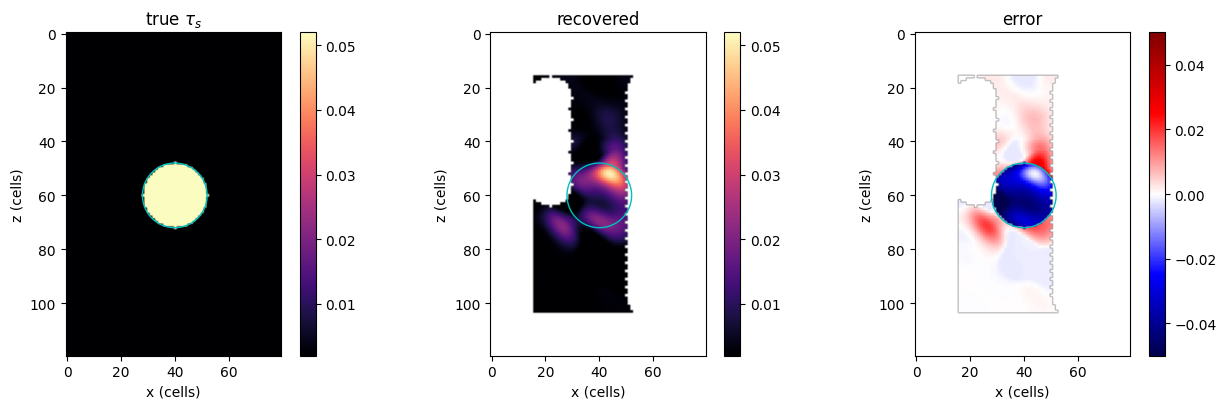

In [7]:
t   = inv.true["taus"]
rec = final["taus"]
s0  = inv.start["taus"]
m   = inv.mask

err0 = np.linalg.norm((s0 - t)[m]); err1 = np.linalg.norm((rec - t)[m])
print("model error: %.4e -> %.4e   (%.1f%% reduction)"
      % (err0, err1, 100*(1 - err1/err0)))
print("recovered peak %.4f (true anomaly %.4f)" % (rec[m].max(), t.max()))

fig, ax = plt.subplots(1, 3, figsize=(13, 4.2))
for a, f, ti in zip(ax, (t, np.where(m, rec, np.nan), np.where(m, rec - t, np.nan)),
                    ("true $\\tau_s$", "recovered", "error")):
    im = a.imshow(f, cmap="magma" if "error" not in ti else "seismic",
                  vmin=0.002 if "error" not in ti else -0.05,
                  vmax=0.052 if "error" not in ti else 0.05)
    a.contour((np.indices(t.shape)[0]-60.)**2 + (np.indices(t.shape)[1]-40.)**2,
              [12.**2], colors="c", linewidths=1)
    a.set_title(ti); a.set_xlabel("x (cells)"); a.set_ylabel("z (cells)")
    plt.colorbar(im, ax=a, fraction=0.046)
plt.tight_layout()

### Reading the result

The anomaly is recovered **in the right place and at the right amplitude**
(peak $\approx 0.051$ against a true $0.052$), but only over its
well-illuminated part. Two reasons, both physical rather than numerical:

* **Crosswell illumination is one-sided.** With sources in one well and
  receivers in the other, the rays crossing the anomaly sample it over a narrow
  range of angles, so the parts of it that are best constrained are the ones
  the ray fan actually crosses.
* **The muted zone removes the wells themselves**, so nothing is recovered
  within 8 cells of either.

Steepest descent then stalls: no step length along $-g$ decreases $J$ further.
That is the accuracy limit of the gradient (the ~19% scatter above), not a bug.
Pushing further needs either a better-conditioned optimiser fed a calibrated
gradient, or more shots — and note that more shots does **not** automatically
help: with all 9 the line search stalls after one iteration.

## 5. Scaling up: the CO$_2$-storage model

The same driver runs on a realistic model — the thesis's CO$_2$-storage
synthetic — by swapping the model dictionary and the acquisition. Nothing in
`Inversion` is specific to the circular inclusion; it takes `true_params` and
`start_params` dicts of `(nz, nx)` arrays keyed `vp`, `vs`, `rho`, `taup`,
`taus`.

```python
true_model  = load_co2_model()                  # dict of (nz, nx) arrays
start_model = smooth_background(true_model)      # or a 1D trend
inv = Inversion(workdir, true_model, start_model,
                gradfreqs=[...], invert=("taup", "taus"),
                mute=8.0, smooth=4.0)
final, J0, J1 = inv.run(niter=30, step0=2.0)
```

Three things change at that scale and are worth setting up deliberately:

1. **Inverting $\tau_p$ and $\tau_s$ together** (`invert=("taup","taus")`)
   doubles the unknowns and introduces a trade-off between them; `Inversion`
   normalises each field by its own starting magnitude so they stay comparably
   scaled.
2. **Frequency continuation.** Start with the lowest usable entries of
   `gradfreqs` and add higher ones in later stages — the standard remedy for
   the local minima that appear once the model has real structure.
3. **A starting model that is not homogeneous.** The circular-inclusion case
   starts from the exact background, so all the error is the anomaly. On a
   realistic model the velocity model must be good enough that the attenuation
   inversion is not absorbing velocity errors.

*The CO$_2$ velocity model is not bundled with the repository; drop it in and
point `load_co2_model()` at it.*